# AutoEncoder on Correlation Matrices
In this notebook we train an AutoEncoder (with non-linear activations) on full correlation matrices, compress them into a latent space, reconstruct them, and evaluate reconstruction quality across different latent dimensions.

In [182]:
from pathlib import Path
import random
import warnings
import sys
import json

import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=4)
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

## Step 1: Load Train/Val/Test Splits
Load correlation matrices and their Cholesky factors from an existing dataset folder containing `train.pt`, `val.pt`, and `test.pt` (each must include `cholesky_L`).
- Local PC: `data/processed/dataset/<DATASET_NAME>`
- Google Colab: `dataset_tesi/<DATASET_NAME>`

In [183]:
FILE_NAME = 'data_00_20'
WINDOW_SIZE = 252
STEP_SIZE = 5
DATASET_NAME = f'{FILE_NAME}_w{WINDOW_SIZE}_s{STEP_SIZE}'
# AE input fixed to Cholesky lower-triangular factors

if 'google.colab' in sys.modules:
    print('Ambiente rilevato: Google Colab')
    IS_COLAB = True
else:
    print('Ambiente rilevato: Locale (PC)')
    IS_COLAB = False

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    base_dir = Path('/content/drive/MyDrive/dataset_tesi')
else:
    project_root = Path.cwd().resolve().parent
    base_dir = project_root / 'data' / 'processed' / FILE_NAME / 'dataset'

dataset_dir = base_dir / DATASET_NAME

TRAIN_FILE = dataset_dir / 'train.pt'
VAL_FILE = dataset_dir / 'val.pt'
TEST_FILE = dataset_dir / 'test.pt'

for split_path in (TRAIN_FILE, VAL_FILE, TEST_FILE):
    if not split_path.exists():
        raise FileNotFoundError(
            f"Errore: Il file '{split_path.name}' non e stato trovato in: {dataset_dir.absolute()}"
        )

print(f'Dataset selezionato: {DATASET_NAME}')
print(f'Train: {TRAIN_FILE.name} | Val: {VAL_FILE.name} | Test: {TEST_FILE.name}')

Ambiente rilevato: Locale (PC)
Dataset selezionato: data_00_20_w252_s5
Train: train.pt | Val: val.pt | Test: test.pt


In [184]:
def load_dataset_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        meta = {k: v for k, v in payload.items() if k not in ('corr_tensor', 'cholesky_L')}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')

    return corr_tensor.float(), meta


train_corr, train_meta = load_dataset_payload(TRAIN_FILE)
val_corr, val_meta = load_dataset_payload(VAL_FILE)
test_corr, test_meta = load_dataset_payload(TEST_FILE)

if train_corr.shape[1:] != test_corr.shape[1:]:
    raise ValueError(f'Train/test asset dims mismatch: {train_corr.shape} vs {test_corr.shape}')
if val_corr.shape[1:] != train_corr.shape[1:]:
    raise ValueError(f'Val/train asset dims mismatch: {val_corr.shape} vs {train_corr.shape}')

print(f'train_corr shape: {tuple(train_corr.shape)}')
print(f'val_corr shape:   {tuple(val_corr.shape)}')
print(f'test_corr shape:  {tuple(test_corr.shape)}')

train_corr shape: (614, 100, 100)
val_corr shape:   (131, 100, 100)
test_corr shape:  (133, 100, 100)


## Step 2: Prepare Matrices from Existing Splits
Use the lower-triangular Cholesky factors as input.
Each matrix is flattened to a vector of length N*(N+1)/2.
Train/val/test come directly from the loaded split files (no random split in notebook).

In [185]:
train_np = train_corr.numpy().astype(np.float32)
val_np = val_corr.numpy().astype(np.float32)
test_np = test_corr.numpy().astype(np.float32)

n_train, n_assets, _ = train_np.shape
n_val = val_np.shape[0]
n_test = test_np.shape[0]
n_matrices = n_train + n_val + n_test

tril_idx = np.tril_indices(n_assets, k=-1)
n_features = len(tril_idx[0])

x_train = torch.from_numpy(train_np[:, tril_idx[0], tril_idx[1]])
x_val = torch.from_numpy(val_np[:, tril_idx[0], tril_idx[1]])
x_test = torch.from_numpy(test_np[:, tril_idx[0], tril_idx[1]])

x_train = x_train.float()
x_val = x_val.float()
x_test = x_test.float()

VAL_FRACTION = n_val / n_matrices
TEST_FRACTION = n_test / n_matrices

print(f'Number of matrices: {n_matrices}')
print(f'Matrix shape: ({n_assets}, {n_assets})')
print(f'Flattened input size: {n_features}')
print(f'Train size: {n_train} | Val size: {n_val} | Test size: {n_test}')

Number of matrices: 878
Matrix shape: (100, 100)
Flattened input size: 4950
Train size: 614 | Val size: 131 | Test size: 133


## Step 3: Define an AutoEncoder
- hidden_dims = None -> linear AE
- hidden_dims = [...] -> AE (ReLU + dropout)

In [186]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], latent_dim: int):
        super().__init__()

        # Encoder
        enc_layers = []
        prev = input_dim
        for h in hidden_dims:
            enc_layers.append(nn.Linear(prev, h))
            enc_layers.append(nn.ReLU())
            prev = h
        self.encoder = nn.Sequential(*enc_layers)

        self.fc_mu = nn.Linear(prev, latent_dim)
        self.fc_logvar = nn.Linear(prev, latent_dim)

        # Decoder
        dec_layers = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            dec_layers.append(nn.Linear(prev, h))
            dec_layers.append(nn.ReLU())
            prev = h
        dec_layers.append(nn.Linear(prev, input_dim))
        dec_layers.append(nn.Tanh())
        self.decoder = nn.Sequential(*dec_layers)

    def encode(self, x: torch.Tensor):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        sample = mu + (eps * std)
        return sample

    def decode(self, z: torch.Tensor):
        return self.decoder(z)

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

## Step 4: Training and Evaluation Utilities
Train the model, reconstruct matrices, and compute reconstruction errors.

In [187]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    recon = torch.nn.functional.mse_loss(x_hat, x, reduction="mean")
    # Average KL divergence per batch
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total = recon + beta * kl
    return total, recon, kl

def train_VAE(
    x_train_tensor: torch.Tensor,
    x_val_tensor: torch.Tensor,
    latent_dim: int,
    hidden_dims=None,
    epochs: int = 80,
    batch_size: int = 64,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    dropout: float = 0.02,
    seed: int = 42,
    scheduler_name: str = 'none',
    cosine_t_max: int = 80,
    cosine_eta_min: float = 1e-8,
    resume_state_dict=None,
    initial_best_val=None,
    beta: float = 1.0,
    ):

    # 1) Seed for reproducibility
    set_seed(seed)

    # 2) Model, optimizer, scheduler
    model = VAE(input_dim=x_train_tensor.shape[1], latent_dim=latent_dim, hidden_dims=hidden_dims).to(device)
    if resume_state_dict is not None:
        model.load_state_dict(resume_state_dict)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler_key = str(scheduler_name).strip().lower()
    valid_schedulers = {'none', 'cosine'}
    if scheduler_key not in valid_schedulers:
        raise ValueError(f"Invalid scheduler '{scheduler_name}'. Choose one of {sorted(valid_schedulers)}")

    scheduler = None
    if scheduler_key == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=cosine_t_max,
            eta_min=cosine_eta_min,
        )

    # 3) DataLoaders
    train_loader = DataLoader(TensorDataset(x_train_tensor), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(x_val_tensor), batch_size=batch_size, shuffle=False)

    # Aggiunti contatori nello storico per le sotto-loss
    history = {
        'train_loss': [], 'train_recon': [], 'train_kl': [],
        'val_loss': [], 'val_recon': [], 'val_kl': [],
        'lr': []
    }

    # 4) Initialization of best validation loss
    if resume_state_dict is not None:
        if initial_best_val is None:
            model.eval()
            val_loss_sum = 0.0
            with torch.no_grad():
                for (xb,) in val_loader:
                    xb = xb.to(device)
                    x_hat, mu, logvar = model(xb)
                    loss, _, _ = vae_loss(x_hat, xb, mu, logvar, beta=beta)
                    val_loss_sum += loss.item() * xb.size(0)
            initial_best_val = val_loss_sum / len(val_loader.dataset)

        best_val = float(initial_best_val)
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        best_val = float('inf')
        best_state = None

    # 5) Training loop
    for epoch in range(epochs):
        model.train()
        
        # Variabili di accumulo per il Train
        train_loss_sum = 0.0
        train_recon_sum = 0.0
        train_kl_sum = 0.0
        current_lr = float(optimizer.param_groups[0]['lr'])

        for (xb,) in train_loader:
            xb = xb.to(device)
            optimizer.zero_grad()
            
            x_hat, mu, logvar = model(xb)
            loss, recon, kl = vae_loss(x_hat, xb, mu, logvar, beta=beta)
            
            loss.backward()
            optimizer.step()
            
            # Accumulo dei valori pesati per la dimensione del batch
            train_loss_sum += loss.item() * xb.size(0)
            train_recon_sum += recon.item() * xb.size(0)
            train_kl_sum += kl.item() * xb.size(0)

        # Calcolo medie per il Train
        train_loss = train_loss_sum / len(train_loader.dataset)
        train_recon = train_recon_sum / len(train_loader.dataset)
        train_kl = train_kl_sum / len(train_loader.dataset)

        model.eval()
        
        # Variabili di accumulo per la Validazione
        val_loss_sum = 0.0
        val_recon_sum = 0.0
        val_kl_sum = 0.0
        
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(device)
                
                x_hat, mu, logvar = model(xb)
                loss, recon, kl = vae_loss(x_hat, xb, mu, logvar, beta=beta)
                
                # Accumulo dei valori
                val_loss_sum += loss.item() * xb.size(0)
                val_recon_sum += recon.item() * xb.size(0)
                val_kl_sum += kl.item() * xb.size(0)

        # Calcolo medie per la Validazione
        val_loss = val_loss_sum / len(val_loader.dataset)
        val_recon = val_recon_sum / len(val_loader.dataset)
        val_kl = val_kl_sum / len(val_loader.dataset)
        
        # Aggiornamento dello storico
        history['train_loss'].append(train_loss)
        history['train_recon'].append(train_recon)
        history['train_kl'].append(train_kl)
        history['val_loss'].append(val_loss)
        history['val_recon'].append(val_recon)
        history['val_kl'].append(val_kl)
        history['lr'].append(current_lr)

        if scheduler is not None:
            if scheduler_key == 'plateau':
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        # STAMPA A SCHERMO FORMATTATA
        print(f'Epoch {epoch + 1:03d}/{epochs} | lr={current_lr:.2e} | Train Loss {train_loss:.6f} (Recon {train_recon:.6f}, KL {train_kl:.6f}) | Val Loss {val_loss:.6f} (Recon {val_recon:.6f}, KL {val_kl:.6f})')

    # 6) Load best state and return
    if best_state is None:
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)

    return model, history, best_val

def reconstruct_matrices(
    model: nn.Module,
    x_tensor: torch.Tensor,
    n_assets: int,
    batch_size: int = 4,
):
    model.eval()
    loader = DataLoader(TensorDataset(x_tensor), batch_size=batch_size, shuffle=False)
    outputs = []

    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            x_hat, _, _ = model(xb) 
            pred = x_hat.cpu().numpy()
            outputs.append(pred)

    # 1. Array flattenato predetto (solo valori strettamente sotto la diagonale)
    recon_flat = np.concatenate(outputs, axis=0).astype(np.float32)
    n_samples = recon_flat.shape[0]

    # 2. Inizializza il batch di matrici quadrate riempite di zeri
    recon_corr = np.zeros((n_samples, n_assets, n_assets), dtype=np.float32)

    # 3. Estrai indici del triangolo inferiore ESCLUSA la diagonale (k=-1)
    tril_idx = np.tril_indices(n_assets, k=-1)

    # 4. SIMMETRIA: Inserisci i valori sia sotto che sopra la diagonale principale
    recon_corr[:, tril_idx[0], tril_idx[1]] = recon_flat
    recon_corr[:, tril_idx[1], tril_idx[0]] = recon_flat

    # 5. DIAGONALE: Inserisci rigorosamente gli 1
    diag_idx = np.arange(n_assets)
    recon_corr[:, diag_idx, diag_idx] = 1.0

    return {
        'recon_corr': recon_corr
    }

def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    diff = original - reconstructed

    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix,
    })

    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats

Device: cuda


In [188]:
if torch.cuda.is_available():
    # 1. Nome della GPU
    print(f"Modello GPU: {torch.cuda.get_device_name(0)}")
    
    # 2. Capacità computazionale (Compute Capability)
    # Indica la generazione dell'architettura (es. 8.9 per le RTX 4000)
    major, minor = torch.cuda.get_device_capability(0)
    print(f"Compute Capability: {major}.{minor}")
    
    # 3. Gestione Memoria (in GB)
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    reserved_memory = torch.cuda.memory_reserved(0) / 1e9
    allocated_memory = torch.cuda.memory_allocated(0) / 1e9
    
    print(f"Memoria Totale: {total_memory:.2f} GB")
    print(f"Memoria Riservata: {reserved_memory:.2f} GB")
    print(f"Memoria in uso: {allocated_memory:.2f} GB")
    
    # 4. Numero di Multiprocetori Streaming (SM)
    # Più alto è il numero, maggiore è il parallelismo
    sm_count = torch.cuda.get_device_properties(0).multi_processor_count
    print(f"Numero di Streaming Multiprocessors: {sm_count}")

else:
    print("GPU non disponibile.")

Modello GPU: NVIDIA GeForce RTX 3060
Compute Capability: 8.6
Memoria Totale: 12.88 GB
Memoria Riservata: 1.61 GB
Memoria in uso: 0.61 GB
Numero di Streaming Multiprocessors: 28


## Step 5: Train One Configuration and Reconstruct Matrices
Train one AE configuration, reconstruct all matrices, and inspect training losses.

In [189]:
SEED = 42
MODEL_TYPE = 'VAE'
LATENT_DIM = 3

RUN = MODEL_TYPE + "_" + str(LATENT_DIM) + "dim_" + "0001"
RESUME_TRAINING = False
RESUME_RUN = MODEL_TYPE + "_" + str(LATENT_DIM) + "dim_" + "0001"

if IS_COLAB:
    RESUME_MODEL_PATH = f"best_models_tesi/{MODEL_TYPE}/{RESUME_RUN}/best_model.pt"
else:
    RESUME_MODEL_PATH = f"models/{DATASET_NAME}/{MODEL_TYPE}/{RESUME_RUN}/best_model.pt"

BETA = 0.1 
EPOCHS = 100
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-6
# Scheduler selector: 'none', 'cosine'
SCHEDULER_NAME = 'cosine'
# CosineAnnealingLR params
COSINE_T_MAX = EPOCHS
COSINE_ETA_MIN = 1e-7

# Hidden layers for the VAE encoder (decoder is mirrored automatically).
# If you resume from an old checkpoint, this must match that checkpoint architecture.
HIDDEN_DIMS = [2048, 1024]

if IS_COLAB:
    run_dir = Path(f'/content/drive/MyDrive/best_models_tesi/{MODEL_TYPE}')
else:
    run_dir = project_root / 'models'/ DATASET_NAME / MODEL_TYPE

run_output_dir = run_dir / RUN
run_output_dir.mkdir(parents=True, exist_ok=True)
print(f'Results directory: {run_output_dir}')
print(f'Resume training: {RESUME_TRAINING}')

Results directory: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\VAE\VAE_3dim_0001
Resume training: False


Epoch 001/100 | lr=1.00e-03 | Train Loss 0.098282 (Recon 0.045941, KL 0.523408) | Val Loss 0.020464 (Recon 0.019880, KL 0.005834)
Epoch 002/100 | lr=1.00e-03 | Train Loss 0.027310 (Recon 0.026669, KL 0.006411) | Val Loss 0.018039 (Recon 0.017727, KL 0.003119)
Epoch 003/100 | lr=9.99e-04 | Train Loss 0.026076 (Recon 0.025701, KL 0.003753) | Val Loss 0.016049 (Recon 0.015983, KL 0.000653)
Epoch 004/100 | lr=9.98e-04 | Train Loss 0.027362 (Recon 0.027173, KL 0.001888) | Val Loss 0.015763 (Recon 0.015580, KL 0.001837)
Epoch 005/100 | lr=9.96e-04 | Train Loss 0.025904 (Recon 0.025718, KL 0.001861) | Val Loss 0.016598 (Recon 0.016514, KL 0.000844)
Epoch 006/100 | lr=9.94e-04 | Train Loss 0.025951 (Recon 0.025716, KL 0.002351) | Val Loss 0.017812 (Recon 0.017412, KL 0.004002)
Epoch 007/100 | lr=9.91e-04 | Train Loss 0.027378 (Recon 0.027039, KL 0.003395) | Val Loss 0.019478 (Recon 0.019301, KL 0.001773)
Epoch 008/100 | lr=9.88e-04 | Train Loss 0.027219 (Recon 0.026881, KL 0.003379) | Val Loss

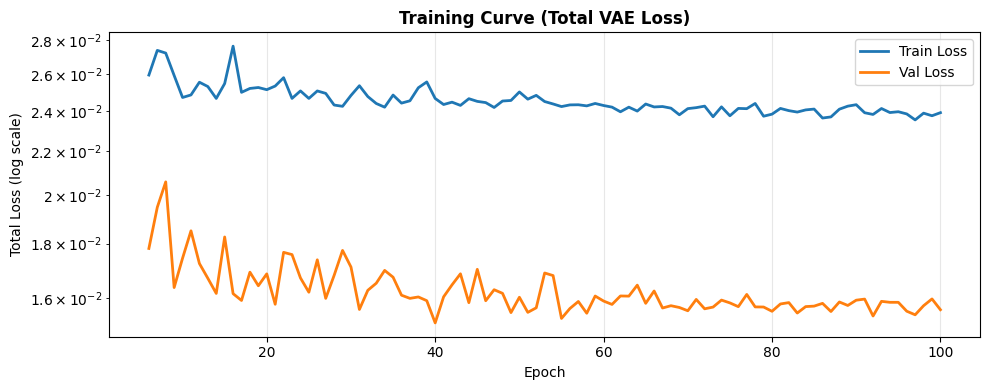

Saved Total Loss curve: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\VAE\VAE_3dim_0001\vae_loss_curve.png


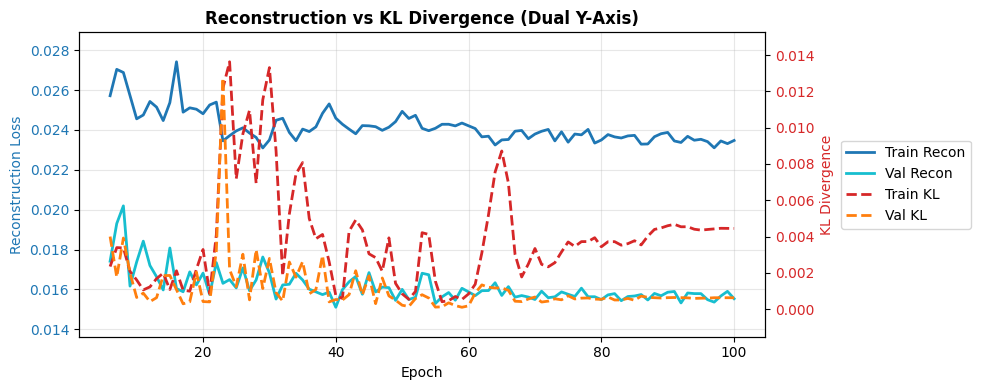

Saved Recon/KL curve: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\VAE\VAE_3dim_0001\recon_kl_curve.png


In [190]:
resume_state_dict = None
resume_initial_val = None
resume_source_path = None

# Resume logic: load checkpoint, check compatibility, extract state dict and initial val loss if available
if RESUME_TRAINING:
    if RESUME_MODEL_PATH is None:
        raise ValueError('RESUME_TRAINING=True but RESUME_MODEL_PATH is None.')

    resume_source_path = Path(RESUME_MODEL_PATH)
    if not resume_source_path.is_absolute():
        if IS_COLAB:
            resume_source_path = Path('/content/drive/MyDrive') / resume_source_path
        else:
            resume_source_path = project_root / resume_source_path
    resume_source_path = resume_source_path.resolve()

    if not resume_source_path.exists():
        raise FileNotFoundError(f'Checkpoint not found: {resume_source_path}')

    checkpoint = torch.load(resume_source_path, map_location=device)
    state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint
    
    # 1. MODIFICA: Usiamo VAE al posto di AutoEncoder
    probe_model = VAE(
        input_dim=x_train.shape[1],
        latent_dim=LATENT_DIM,
        hidden_dims=HIDDEN_DIMS,
    )
    current_shapes = {k: tuple(v.shape) for k, v in probe_model.state_dict().items()}
    loaded_shapes = {k: tuple(v.shape) for k, v in state_dict.items()}

    missing_keys = [k for k in current_shapes.keys() if k not in loaded_shapes]
    unexpected_keys = [k for k in loaded_shapes.keys() if k not in current_shapes]
    shape_mismatches = [
        (k, loaded_shapes[k], current_shapes[k])
        for k in current_shapes.keys()
        if k in loaded_shapes and loaded_shapes[k] != current_shapes[k]
    ]

    if missing_keys or shape_mismatches or unexpected_keys:
        suggested_hidden = []
        # Cerchiamo tutti i pesi dei layer lineari nell'encoder
        for key, weight in state_dict.items():
            if key.startswith('encoder.') and key.endswith('.weight'):
                # Escludiamo il primo strato (input_dim -> hidden[0])
                if weight.shape[1] == x_train.shape[1]:
                    continue
                suggested_hidden.append(int(weight.shape[0]))

        # L'ultimo elemento trovato sara il latent_dim
        if suggested_hidden:
            ckpt_latent_dim = suggested_hidden[-1]
            ckpt_hidden_dims = suggested_hidden[:-1]
            hint = (
                f'Checkpoint expects latent_dim={ckpt_latent_dim}, '
                f'hidden_dims={ckpt_hidden_dims}. '
                'Set these values to match before resuming, or start a new run without resume.'
            )
        else:
            hint = 'Checkpoint architecture could not be inferred. Use a checkpoint saved with the same model architecture.'

        details = []
        if missing_keys:
            details.append(f'Missing keys (first 5): {missing_keys[:5]}')
        if unexpected_keys:
            details.append(f'Unexpected keys (first 5): {unexpected_keys[:5]}')
        if shape_mismatches:
            k, loaded_shape, current_shape = shape_mismatches[0]
            details.append(f'Shape mismatch example: {k} loaded={loaded_shape}, current={current_shape}')

        raise RuntimeError(
            'Incompatible checkpoint for current VAE architecture. ' + hint + (' | ' + ' ; '.join(details) if details else '')
        )

    resume_state_dict = state_dict
    if isinstance(checkpoint, dict) and 'best_val_loss' in checkpoint:
        resume_initial_val = float(checkpoint['best_val_loss'])

    if resume_initial_val is None:
        # 2. MODIFICA: Usiamo VAE e rimuoviamo linear_bias
        temp_model = VAE(
            input_dim=x_train.shape[1],
            latent_dim=LATENT_DIM,
            hidden_dims=HIDDEN_DIMS,
        ).to(device)
        temp_model.load_state_dict(resume_state_dict)
        temp_model.eval()

        val_loader = DataLoader(TensorDataset(x_val), batch_size=BATCH_SIZE, shuffle=False)
        val_loss_sum = 0.0
        with torch.no_grad():
            for (xb,) in val_loader:
                xb = xb.to(device)
                
                # 3. MODIFICA: Disimballiamo l'output del VAE e calcoliamo la vae_loss
                x_hat, mu, logvar = temp_model(xb)
                loss, _, _ = vae_loss(x_hat, xb, mu, logvar, beta=BETA)
                
                val_loss_sum += loss.item() * xb.size(0)
        resume_initial_val = val_loss_sum / len(val_loader.dataset)

    print(f'Loaded checkpoint: {resume_source_path}')
    print(f'Checkpoint validation Loss (baseline for resume): {resume_initial_val:.6f}')

# Train the model (or resume training if applicable)
model, history, best_val = train_VAE(
    x_train_tensor=x_train,
    x_val_tensor=x_val,
    latent_dim=LATENT_DIM,
    hidden_dims=HIDDEN_DIMS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    seed=SEED,
    scheduler_name=SCHEDULER_NAME,
    cosine_t_max=COSINE_T_MAX,
    cosine_eta_min=COSINE_ETA_MIN,
    resume_state_dict=resume_state_dict,
    initial_best_val=resume_initial_val,
    beta=BETA, # Aggiunto il passaggio del parametro beta
)

# --- SALVATAGGIO DEL MODELLO ---
best_model_path = run_output_dir / 'best_model.pt'
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'model_config': {
            'input_dim': int(x_train.shape[1]),
            'latent_dim': int(LATENT_DIM),
            'hidden_dims': HIDDEN_DIMS,
            'epochs': int(EPOCHS),
            'batch_size': int(BATCH_SIZE),
            'lr': float(LR),
            'weight_decay': float(WEIGHT_DECAY),
            'seed': int(SEED),
            'scheduler': {
                'key': str(SCHEDULER_NAME).strip().lower(),
            },
            'beta': float(BETA),
        },
        'best_val_loss': float(best_val),
    },
    best_model_path,
)
print(f'Saved best model: {best_model_path}')
print(f'Best validation loss: {best_val:.6f}')

# --- PLOTTING DELLE CURVE DI LOSS ---
total_epochs = len(history['train_loss'])
if total_epochs == 0:
    print('No training history to plot.')
else:
    # Preparazione degli assi e degli indici
    epochs_arr = np.arange(1, total_epochs + 1)
    start_idx = 5 if total_epochs > 5 else 0
    ep_plot = epochs_arr[start_idx:]

    # ==========================================
    # GRAFICO 1: VAE Loss Totale
    # ==========================================
    fig1, ax1 = plt.subplots(figsize=(10, 4))
    ax1.plot(ep_plot, history["train_loss"][start_idx:], label="Train Loss", linewidth=2)
    ax1.plot(ep_plot, history["val_loss"][start_idx:], label="Val Loss", linewidth=2)
    
    ax1.set_title('Training Curve (Total VAE Loss)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_yscale('log')
    ax1.set_ylabel('Total Loss (log scale)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    plt.tight_layout()

    # SALVATAGGIO PRIMA DI MOSTRARE
    loss_curve_path = run_output_dir / 'vae_loss_curve.png'
    fig1.savefig(loss_curve_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig1) # Libera la memoria
    print(f'Saved Total Loss curve: {loss_curve_path}')


    # ==========================================
    # GRAFICO 2: Reconstruction (asse sx) vs KL Divergence (asse dx)
    # ==========================================
    train_recon = np.asarray(history["train_recon"][start_idx:])
    val_recon = np.asarray(history["val_recon"][start_idx:])
    train_kl = np.asarray(history["train_kl"][start_idx:])
    val_kl = np.asarray(history["val_kl"][start_idx:])

    def axis_limits(values_1, values_2, margin_ratio=0.1):
        y_min = float(min(values_1.min(), values_2.min()))
        y_max = float(max(values_1.max(), values_2.max()))
        span = y_max - y_min
        if span == 0:
            span = max(abs(y_max), 1e-6)
        margin = span * margin_ratio
        return y_min - margin, y_max + margin

    fig2, ax_recon = plt.subplots(figsize=(10, 4))
    ax_kl = ax_recon.twinx()

    # Tracciamo le curve
    l1, = ax_recon.plot(ep_plot, train_recon, color="tab:blue", linewidth=2, label="Train Recon")
    l2, = ax_recon.plot(ep_plot, val_recon, color="tab:cyan", linewidth=2, label="Val Recon")
    l3, = ax_kl.plot(ep_plot, train_kl, color="tab:red", linestyle="--", linewidth=2, label="Train KL")
    l4, = ax_kl.plot(ep_plot, val_kl, color="tab:orange", linestyle="--", linewidth=2, label="Val KL")

    # Impostiamo i limiti degli assi dinamicamente
    recon_ymin, recon_ymax = axis_limits(train_recon, val_recon, margin_ratio=0.12)
    kl_ymin, kl_ymax = axis_limits(train_kl, val_kl, margin_ratio=0.12)
    ax_recon.set_ylim(recon_ymin, recon_ymax)
    ax_kl.set_ylim(kl_ymin, kl_ymax)

    # Etichette e colori
    ax_recon.set_xlabel("Epoch")
    ax_recon.set_ylabel("Reconstruction Loss", color="tab:blue")
    ax_kl.set_ylabel("KL Divergence", color="tab:red")
    ax_recon.tick_params(axis="y", labelcolor="tab:blue")
    ax_kl.tick_params(axis="y", labelcolor="tab:red")
    ax_recon.set_title("Reconstruction vs KL Divergence (Dual Y-Axis)", fontsize=12, fontweight='bold')
    ax_recon.grid(True, alpha=0.3)

    # Legenda combinata
    lines = [l1, l2, l3, l4]
    labels = [line.get_label() for line in lines]
    # Posiziona la legenda fuori dal grafico per evitare che copra le linee
    ax_recon.legend(lines, labels, loc="center left", bbox_to_anchor=(1.1, 0.5))

    fig2.tight_layout()
    
    # SALVATAGGIO PRIMA DI MOSTRARE
    recon_kl_path = run_output_dir / 'recon_kl_curve.png'
    fig2.savefig(recon_kl_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig2) # Libera la memoria
    print(f'Saved Recon/KL curve: {recon_kl_path}')

In [191]:
print(model)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=4950, out_features=2048, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=1024, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=1024, out_features=3, bias=True)
  (fc_logvar): Linear(in_features=1024, out_features=3, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=2048, bias=True)
    (3): ReLU()
    (4): Linear(in_features=2048, out_features=4950, bias=True)
    (5): Tanh()
  )
)


## Step 6: Matrix-Level Reconstruction Visualization
Show the same reconstruction plots used in the PCA notebook: clustered heatmaps and standard heatmaps (original, reconstructed, error).

Original Matrix:
[[1.     0.2769 0.0446 0.1545 0.341 ]
 [0.2769 1.     0.1668 0.3001 0.3637]
 [0.0446 0.1668 1.     0.2089 0.2174]
 [0.1545 0.3001 0.2089 1.     0.2227]
 [0.341  0.3637 0.2174 0.2227 1.    ]]
Reconstructed Matrix:
[[1.     0.3583 0.2855 0.2894 0.2745]
 [0.3583 1.     0.3732 0.4024 0.3952]
 [0.2855 0.3732 1.     0.3475 0.2793]
 [0.2894 0.4024 0.3475 1.     0.4002]
 [0.2745 0.3952 0.2793 0.4002 1.    ]]
Error Matrix:
[[ 0.      0.0813  0.2409  0.1348 -0.0665]
 [ 0.0813  0.      0.2065  0.1023  0.0315]
 [ 0.2409  0.2065  0.      0.1386  0.0619]
 [ 0.1348  0.1023  0.1386  0.      0.1775]
 [-0.0665  0.0315  0.0619  0.1775  0.    ]]
Sample index: 0
MSE: 0.025631 | MAE: 0.132614 | Frobenius: 16.009750
Error range - Min: -0.292393 | Max: 0.490629


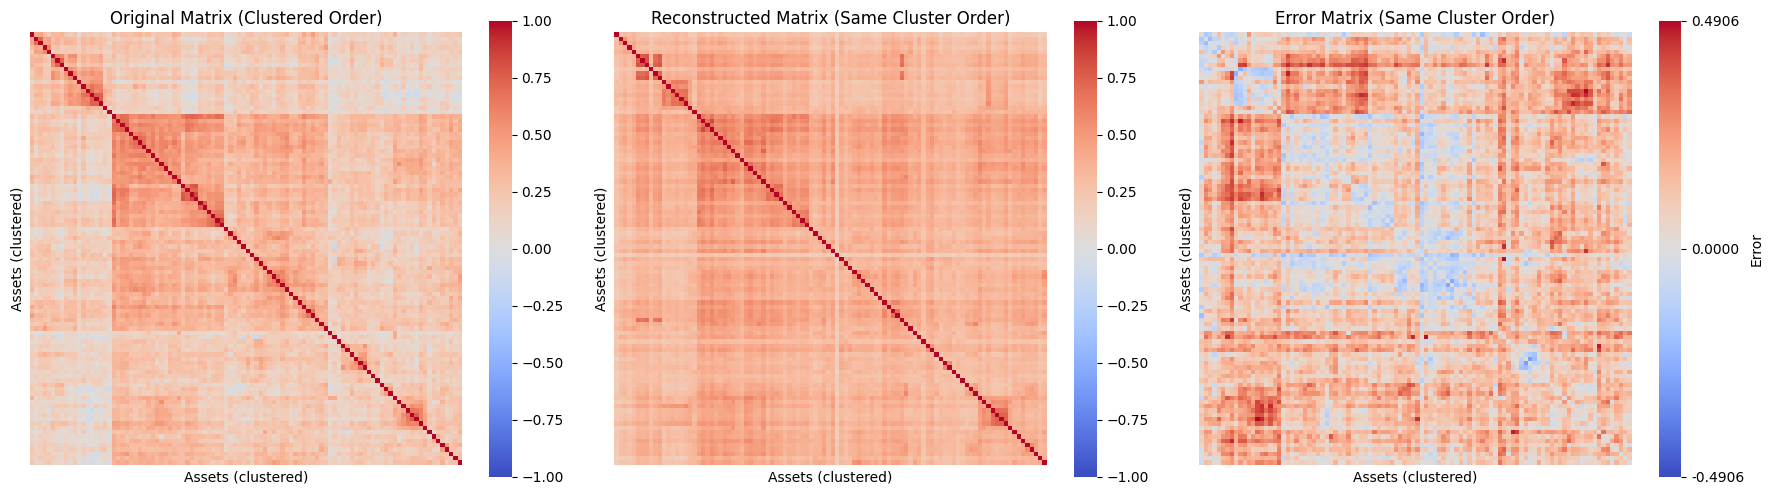

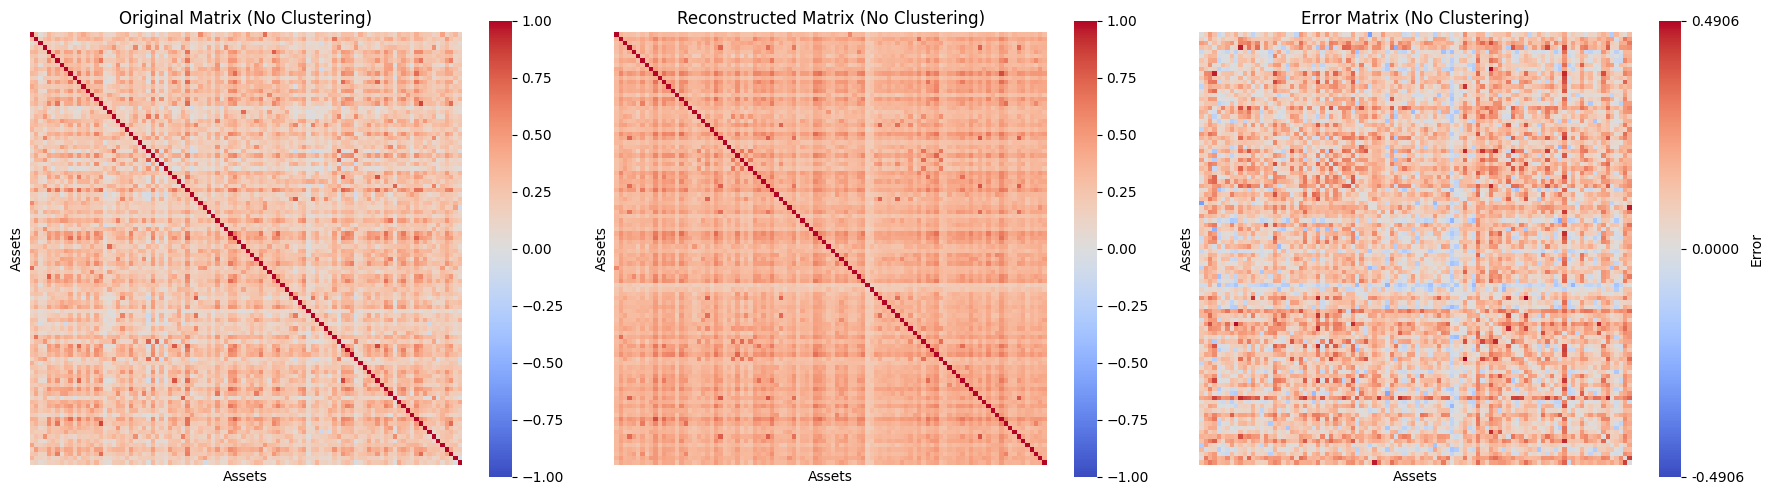

Saved heatmaps for matrix index 0:
 - C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\VAE\VAE_3dim_0001\heatmaps\idx0\clustered_heatmaps.png
 - C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\VAE\VAE_3dim_0001\heatmaps\idx0\standard_heatmaps.png


In [192]:
recon_out = reconstruct_matrices(model, x_test, n_assets=n_assets)
recon_corr = recon_out['recon_corr']

SAMPLE_IDX = 0

if not (0 <= SAMPLE_IDX < test_np.shape[0]):
    raise ValueError(f'SAMPLE_IDX must be in [0, {test_np.shape[0] - 1}]')

orig_mat = test_np[SAMPLE_IDX]
recon_mat = recon_corr[SAMPLE_IDX]
err_mat = recon_mat - orig_mat

print(f"Original Matrix:\n{orig_mat[:5, :5]}")  # Print the top-left 5x5 block of the original matrix for inspection
print(f"Reconstructed Matrix:\n{recon_mat[:5, :5]}")  # Print the top-left 5x5 block of the reconstructed matrix for inspection
print(f"Error Matrix:\n{err_mat[:5, :5]}")  # Print the top-left 5x5 block of the error matrix for inspection

mse_sample = float(np.mean((recon_mat - orig_mat) ** 2))
mae_sample = float(np.mean(np.abs(recon_mat - orig_mat)))
fro_sample = float(np.linalg.norm(recon_mat - orig_mat, ord='fro'))

print(f'Sample index: {SAMPLE_IDX}')
print(f'MSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')

heatmap_base_dir = run_output_dir / 'heatmaps'
heatmap_base_dir.mkdir(parents=True, exist_ok=True)
heatmap_dir = heatmap_base_dir / f'idx{SAMPLE_IDX}'
heatmap_dir.mkdir(parents=True, exist_ok=True)

shared_cmap = 'coolwarm'
err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

# Build a single cluster ordering from the original matrix and reuse it for all three panels.
cluster_ref = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.fig)

orig_mat_clustered = orig_mat[np.ix_(row_order, col_order)]
recon_mat_clustered = recon_mat[np.ix_(row_order, col_order)]
err_mat_clustered = err_mat[np.ix_(row_order, col_order)]

fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    orig_mat_clustered,
    ax=axes_cluster[0],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[0].set_title('Original Matrix (Clustered Order)')

sns.heatmap(
    recon_mat_clustered,
    ax=axes_cluster[1],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
)
axes_cluster[1].set_title('Reconstructed Matrix (Same Cluster Order)')

hm_cluster_err = sns.heatmap(
    err_mat_clustered,
    ax=axes_cluster[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_cluster[2].set_title('Error Matrix (Same Cluster Order)')

cbar_cluster = hm_cluster_err.collections[0].colorbar
cbar_cluster.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_cluster.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes_cluster:
    ax.set_xlabel('Assets (clustered)')
    ax.set_ylabel('Assets (clustered)')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_cluster_all = heatmap_dir / 'clustered_heatmaps.png'
fig_cluster.savefig(path_cluster_all, dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

hm = sns.heatmap(
    err_mat,
    ax=axes[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes[2].set_title('Error Matrix (No Clustering)')

cbar_std = hm.collections[0].colorbar
cbar_std.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_std.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
path_standard = heatmap_dir / 'standard_heatmaps.png'
fig.savefig(path_standard, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved heatmaps for matrix index {SAMPLE_IDX}:')
print(f' - {path_cluster_all}')
print(f' - {path_standard}')

## Step 7: Reconstruction Error Statistics
Compute error statistics on train/test for both reconstructed matrices and Cholesky input vectors.

In [193]:
# Compute error statistics on train/test for matrices and Cholesky vectors
recon_out_test = reconstruct_matrices(model, x_test, n_assets=n_assets)
recon_corr_test = recon_out_test['recon_corr']

recon_out_train = reconstruct_matrices(model, x_train, n_assets=n_assets)
recon_corr_train = recon_out_train['recon_corr']

errors_df_test_matrix, errors_stats_test_matrix = reconstruction_errors(test_np, recon_corr_test)
errors_df_train_matrix, errors_stats_train_matrix = reconstruction_errors(train_np, recon_corr_train)

print('Reconstruction error statistics (Train Set, matrices):')
display(errors_stats_train_matrix)
print('Reconstruction error statistics (Test Set, matrices):')
display(errors_stats_test_matrix)

Reconstruction error statistics (Train Set, matrices):


,mean,std,min,median,max
MSE,0.023918,0.014646,0.006513,0.021298,0.072038
MAE,0.127637,0.045464,0.064671,0.124057,0.254159
Frobenius,14.799161,4.494356,8.070478,14.593955,26.839808


Reconstruction error statistics (Test Set, matrices):


,mean,std,min,median,max
MSE,0.031239,0.018488,0.012963,0.023000,0.076131
MAE,0.141420,0.049450,0.089826,0.121056,0.248146
Frobenius,16.965206,4.975677,11.385372,15.165668,27.591782


In [194]:
results_path = run_output_dir / 'run_results.json'

recon_stats_payload = None
if 'errors_stats_test_matrix' in globals():
    recon_stats_payload = {
        'test_matrix': errors_stats_test_matrix.astype(float).to_dict(orient='index'),
        'train_matrix': errors_stats_train_matrix.astype(float).to_dict(orient='index'),
    }

scheduler_key = str(SCHEDULER_NAME).strip().lower()

if scheduler_key == 'none':
    scheduler_payload = None
elif scheduler_key == 'cosine':
    scheduler_payload = {
        'key': scheduler_key,
        'T_max': int(COSINE_T_MAX),
        'eta_min': float(COSINE_ETA_MIN),
    }

resumed = bool(RESUME_TRAINING)
if resumed:
    resume_info = {
        'source_model_path': str(resume_source_path) if resume_source_path is not None else None,
        'initial_best_val': float(resume_initial_val) if resume_initial_val is not None else None,
    }
else:
    resume_info = None

hidden_dims_info = [int(x) for x in HIDDEN_DIMS]

results_payload = {
    'run': RUN,
    'seed': int(SEED),
    'dataset_info': {
        'dataset_name': DATASET_NAME,
        'n_matrices': int(n_matrices),
        'n_assets': int(n_assets),
        'n_features': int(n_features),
        'splits': {
            'train_size': int(n_train),
            'val_size': int(n_val),
            'test_size': int(n_test),
            'val_fraction': round(float(VAL_FRACTION), 2),
            'test_fraction': round(float(TEST_FRACTION), 2),
        },
    },
    'model': {
        'model_type': MODEL_TYPE,
        'latent_dim': int(LATENT_DIM),
        'hidden_dims': hidden_dims_info,
        'epochs': int(EPOCHS),
        'batch_size': int(BATCH_SIZE),
        'lr': float(LR),
        'weight_decay': float(WEIGHT_DECAY),
        'beta': float(BETA) if 'BETA' in globals() else 1.0, # VAE ADDITION: salvataggio del beta
        'scheduler': scheduler_payload,
        'best_val_loss': float(best_val) if 'best_val' in globals() else None,
        'resume': resume_info,
    },
    'artifacts': {
        'best_model_path': str(best_model_path) if 'best_model_path' in globals() else None,
        'training_curve_path': str(loss_curve_path) if 'loss_curve_path' in globals() else None,
    },
    'metrics': {
        'reconstruction_stats': recon_stats_payload,
    },
    'loss_history': {
        # Loss Totale e Learning Rate
        'train_loss': [float(x) for x in history['train_loss']],
        'val_loss': [float(x) for x in history['val_loss']],
        'lr': [float(x) for x in history['lr']] if 'lr' in history else None,
        
        # VAE ADDITION: Componenti separate della Loss
        'train_recon': [float(x) for x in history['train_recon']] if 'train_recon' in history else None,
        'val_recon': [float(x) for x in history['val_recon']] if 'val_recon' in history else None,
        'train_kl': [float(x) for x in history['train_kl']] if 'train_kl' in history else None,
        'val_kl': [float(x) for x in history['val_kl']] if 'val_kl' in history else None,
    },
}

with open(results_path, 'w', encoding='utf-8') as f:
    json.dump(results_payload, f, indent=4)

print(f'Saved results: {results_path}')

Saved results: C:\Users\dylan\Desktop\TESI\SyntheticCorrelationVAE\PROGETTO_TESI_DYLAN\models\data_00_20_w252_s5\VAE\VAE_3dim_0001\run_results.json
